In [1]:
import sys
import os
project_root = os.path.abspath("..")
sys.path.append(project_root)

print("Added to PYTHONPATH:", project_root)

Added to PYTHONPATH: /vols/cms/mm1221/geant4sim/scripts/validation_new


In [2]:
import pandas as pd
import glob
import os

def load_csv_folder_with_event_offset(folder, event_col="event_id"):
    csv_files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    assert len(csv_files) > 0, f"No CSV files found in {folder}"

    dfs = []
    event_offset = 0

    for f in csv_files:
        df = pd.read_csv(f)
        if event_col not in df.columns:
            raise ValueError(f"{event_col} not found in {f}")
        n_events = df[event_col].nunique()
        df[event_col] += event_offset

        dfs.append(df)
        event_offset += n_events

    return pd.concat(dfs, ignore_index=True)


In [22]:
df_contrastive = load_csv_folder_with_event_offset("../dfs")
df_oc          = load_csv_folder_with_event_offset("../dfs")

print(df_contrastive["event_id"].min(), df_contrastive["event_id"].max())
print(df_oc["event_id"].min(), df_oc["event_id"].max())


0 1449
0 1449


In [23]:
df_contrastive = df_contrastive[df_contrastive["reco_energy"] >= 100].reset_index(drop=True)
df_oc = df_oc[df_oc["reco_energy"] >= 100].reset_index(drop=True)

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from src.metrics.calculations import calc_purity, calc_efficiency

# 1) Efficiency binning

all_cp = np.concatenate([
    df_contrastive["PrimaryEnergy"].values,
    df_oc["PrimaryEnergy"].values,
])

n_bins = 10
cp_bins = np.linspace(all_cp.min(), all_cp.max(), n_bins + 1)
cp_bin_centers = 0.5 * (cp_bins[:-1] + cp_bins[1:])

eff_contrastive = []
eff_oc = []

for i in range(n_bins):
    low, high = cp_bins[i], cp_bins[i + 1]

    df_c_bin = df_contrastive[(df_contrastive["PrimaryEnergy"] >= low) &
                               (df_contrastive["PrimaryEnergy"] < high)]
    df_oc_bin = df_oc[(df_oc["PrimaryEnergy"] >= low) &
                      (df_oc["PrimaryEnergy"] < high)]

    eff_contrastive.append(calc_efficiency(df_c_bin, threshold=0.5))
    eff_oc.append(calc_efficiency(df_oc_bin, threshold=0.5))


# 2) Purity binning

LOW = 96.6786064746
HIGH = 2496.96516186

df_c_restricted = df_contrastive[(df_contrastive["reco_energy"] >= LOW) &
                                 (df_contrastive["reco_energy"] <= HIGH)]
df_oc_restricted = df_oc[(df_oc["reco_energy"] >= LOW) &
                         (df_oc["reco_energy"] <= HIGH)]

reco_bins = np.linspace(LOW, HIGH, n_bins + 1)
reco_bin_centers = 0.5 * (reco_bins[:-1] + reco_bins[1:])

purity_contrastive = []
purity_oc = []

for i in range(n_bins):
    low, high = reco_bins[i], reco_bins[i + 1]

    df_c_bin = df_c_restricted[(df_c_restricted["reco_energy"] >= low) &
                               (df_c_restricted["reco_energy"] < high)]
    df_oc_bin = df_oc_restricted[(df_oc_restricted["reco_energy"] >= low) &
                                 (df_oc_restricted["reco_energy"] < high)]

    purity_contrastive.append(calc_purity(df_c_bin, threshold=0.2) if len(df_c_bin) else np.nan)
    purity_oc.append(calc_purity(df_oc_bin, threshold=0.2) if len(df_oc_bin) else np.nan)

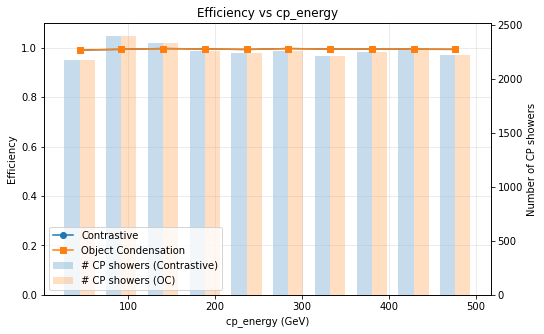

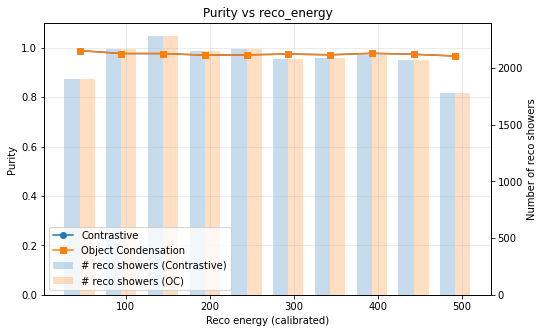

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Robust histogram helpers (counts unique showers, not rows)

def _bin_index(values, bins):
    """Return bin indices 0..(nbins-1) using [low, high) convention (last bin includes right edge)."""
    v = np.asarray(values)
    idx = np.digitize(v, bins, right=False) - 1
    valid = np.isfinite(v) & (idx >= 0) & (idx < len(bins) - 1)
    return idx[valid]

def counts_per_bin_unique(df, value_col, bins, *, event_col="event_id", id_col=None, mask=None):
    """
    Count UNIQUE objects per bin.
    - If id_col is provided: count unique (event_id, id_col) objects (e.g. CPs or reco clusters) per bin.
    - mask is applied BEFORE dropping duplicates.
    """
    if mask is not None:
        d = df.loc[mask, [value_col] + ([event_col] if event_col in df.columns else []) + ([id_col] if id_col else [])]
    else:
        d = df[[value_col] + ([event_col] if event_col in df.columns else []) + ([id_col] if id_col else [])]

    d = d[np.isfinite(d[value_col].to_numpy())]

    if id_col is not None:
        if event_col not in d.columns:
            raise ValueError(f"event_col='{event_col}' not in df columns; needed to count unique objects per event.")
        d = d.drop_duplicates(subset=[event_col, id_col])

    idx = _bin_index(d[value_col].to_numpy(), bins)
    return np.bincount(idx, minlength=len(bins) - 1)


# Efficiency plot + CP histogram background 

EVENT_COL = "event_id"
CP_ID_COL = "cp_id"         

cp_counts_c  = counts_per_bin_unique(df_contrastive, "PrimaryEnergy", cp_bins, event_col=EVENT_COL, id_col=CP_ID_COL)
cp_counts_oc = counts_per_bin_unique(df_oc,          "PrimaryEnergy", cp_bins, event_col=EVENT_COL, id_col=CP_ID_COL)

# bin widths in GeV for bar plotting
cp_bin_centers_GeV = cp_bin_centers / 1000.0
cp_bin_widths_GeV  = (cp_bins[1:] - cp_bins[:-1]) / 1000.0

fig, ax = plt.subplots(figsize=(8, 5))
ax_counts = ax.twinx()

offset = 0.18 * cp_bin_widths_GeV
ax_counts.bar(cp_bin_centers_GeV - offset, cp_counts_c,
              width=0.36 * cp_bin_widths_GeV,
              alpha=0.25, label="# CP showers (Contrastive)")
ax_counts.bar(cp_bin_centers_GeV + offset, cp_counts_oc,
              width=0.36 * cp_bin_widths_GeV,
              alpha=0.25, label="# CP showers (OC)")

ax.set_zorder(2)
ax.patch.set_alpha(0.0)
ax_counts.set_zorder(1)

ax.plot(cp_bin_centers_GeV, eff_contrastive, "o-", label="Contrastive")
ax.plot(cp_bin_centers_GeV, eff_oc, "s-", label="Object Condensation")

ax.set_xlabel("cp_energy (GeV)")
ax.set_ylabel("Efficiency")
ax.set_title("Efficiency vs cp_energy")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

ax_counts.set_ylabel("Number of CP showers")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_counts.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best")

plt.show()


# Purity plot + reco histogram background 

CAL = 2.06871e-01  # energy calibration factor

# reco energies 
reco_vals_c  = df_contrastive["reco_energy"].to_numpy()
reco_vals_oc = df_oc["reco_energy"].to_numpy()

mask_c  = np.isfinite(reco_vals_c)  & (reco_vals_c  >= LOW) & (reco_vals_c  <= HIGH)
mask_oc = np.isfinite(reco_vals_oc) & (reco_vals_oc >= LOW) & (reco_vals_oc <= HIGH)

# Count reco showers 
RECO_ID_COL = "reco_id"  
reco_counts_c  = counts_per_bin_unique(df_contrastive, "reco_energy", reco_bins, event_col=EVENT_COL, id_col=RECO_ID_COL, mask=mask_c)
reco_counts_oc = counts_per_bin_unique(df_oc,          "reco_energy", reco_bins, event_col=EVENT_COL, id_col=RECO_ID_COL, mask=mask_oc)

reco_bin_centers_cal = reco_bin_centers * CAL
reco_bin_widths_cal  = (reco_bins[1:] - reco_bins[:-1]) * CAL

fig, ax = plt.subplots(figsize=(8, 5))
ax_counts = ax.twinx()

offset = 0.18 * reco_bin_widths_cal

ax_counts.bar(
    reco_bin_centers_cal - offset,
    reco_counts_c,
    width=0.36 * reco_bin_widths_cal,
    alpha=0.25,
    label="# reco showers (Contrastive)",
)
ax_counts.bar(
    reco_bin_centers_cal + offset,
    reco_counts_oc,
    width=0.36 * reco_bin_widths_cal,
    alpha=0.25,
    label="# reco showers (OC)",
)

ax.set_zorder(2)
ax.patch.set_alpha(0.0)
ax_counts.set_zorder(1)

ax.plot(reco_bin_centers_cal, purity_contrastive, "o-", label="Contrastive")
ax.plot(reco_bin_centers_cal, purity_oc, "s-", label="Object Condensation")

ax.set_xlabel("Reco energy (calibrated)")
ax.set_ylabel("Purity")
ax.set_title("Purity vs reco_energy")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

ax_counts.set_ylabel("Number of reco showers")

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_counts.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="best")

plt.show()


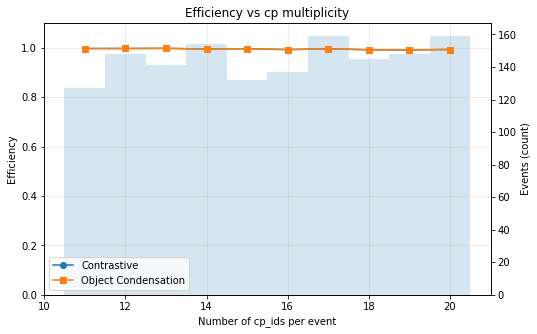

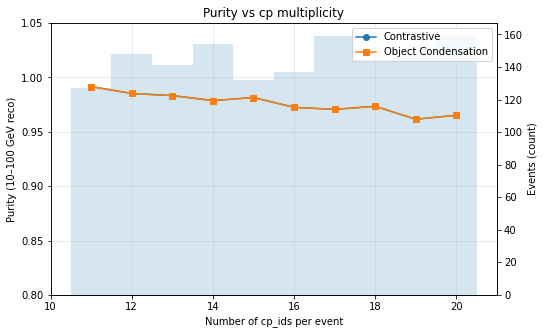

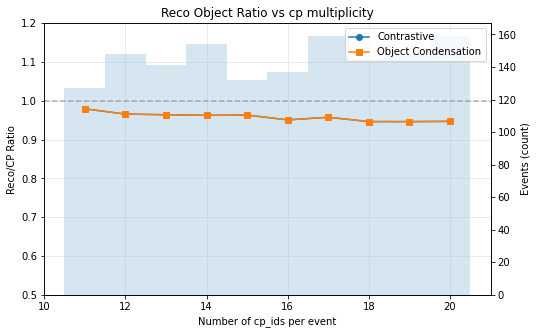

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from src.metrics.calculations import calc_purity, calc_efficiency, calc_ratio

# 0) Compute cp multiplicity per event

cp_per_event = (
    df_contrastive[["event_id", "cp_id"]]
    .drop_duplicates()
    .groupby("event_id")["cp_id"]
    .nunique()
)

multiplicities = np.sort(cp_per_event.unique())

# Histogram data: how many events at each multiplicity
m_values = cp_per_event.values.astype(int)
m_min, m_max = int(m_values.min()), int(m_values.max())
hist_bins = np.arange(m_min - 0.5, m_max + 1.5, 1.0)  
hist_counts, hist_edges = np.histogram(m_values, bins=hist_bins)

# 1) Efficiency vs multiplicity

eff_contrastive = []
eff_oc = []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m = df_contrastive[df_contrastive["event_id"].isin(event_ids_m)]
    df_oc_m = df_oc[df_oc["event_id"].isin(event_ids_m)]

    eff_contrastive.append(calc_efficiency(df_c_m, threshold=0.5) if len(df_c_m) else np.nan)
    eff_oc.append(calc_efficiency(df_oc_m, threshold=0.5) if len(df_oc_m) else np.nan)

# 2) Purity vs multiplicity

LOW = 100.6786064746
HIGH = 2416.96516186

df_c_res = df_contrastive[(df_contrastive["reco_energy"] >= LOW) &
                          (df_contrastive["reco_energy"] <= HIGH)]
df_oc_res = df_oc[(df_oc["reco_energy"] >= LOW) &
                  (df_oc["reco_energy"] <= HIGH)]

purity_contrastive = []
purity_oc = []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m_r = df_c_res[df_c_res["event_id"].isin(event_ids_m)]
    df_oc_m_r = df_oc_res[df_oc_res["event_id"].isin(event_ids_m)]

    purity_contrastive.append(calc_purity(df_c_m_r, threshold=0.2) if len(df_c_m_r) else np.nan)
    purity_oc.append(calc_purity(df_oc_m_r, threshold=0.2) if len(df_oc_m_r) else np.nan)

# 3) Number Ratio vs multiplicity

ratio_contrastive = []
ratio_oc = []

for m in multiplicities:
    event_ids_m = cp_per_event.index[cp_per_event == m]

    df_c_m = df_contrastive[df_contrastive["event_id"].isin(event_ids_m)]
    df_oc_m = df_oc[df_oc["event_id"].isin(event_ids_m)]

    ratio_contrastive.append(calc_ratio(df_c_m) if len(df_c_m) else np.nan)
    ratio_oc.append(calc_ratio(df_oc_m) if len(df_oc_m) else np.nan)

# Helper: add multiplicity histogram as plot background
def add_multiplicity_hist_background(ax, hist_edges, hist_counts, alpha=0.18):
    """
    Adds a histogram of event counts vs cp multiplicity behind the main plot.

    Drawn on a twin y-axis so it doesn't distort the main y-scale.
    """
    ax2 = ax.twinx()

    # Draw bars centered on integer multiplicities
    widths = np.diff(hist_edges)
    lefts = hist_edges[:-1]
    ax2.bar(lefts, hist_counts, width=widths, align="edge", alpha=alpha)

    ax2.set_ylabel("Events (count)")
    ax2.grid(False)

    # Keep histogram behind the lines/markers
    ax2.set_zorder(0)
    ax.set_zorder(1)
    ax.patch.set_alpha(0) 

    return ax2

# 4) Plots 

# Efficiency Plot
fig, ax = plt.subplots(figsize=(8, 5))
add_multiplicity_hist_background(ax, hist_edges, hist_counts, alpha=0.18)

ax.plot(multiplicities, eff_contrastive, "o-", label="Contrastive")
ax.plot(multiplicities, eff_oc, "s-", label="Object Condensation")
ax.set_xlabel("Number of cp_ids per event")
ax.set_ylabel("Efficiency")
ax.set_title("Efficiency vs cp multiplicity")
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Purity Plot 
fig, ax = plt.subplots(figsize=(8, 5))
add_multiplicity_hist_background(ax, hist_edges, hist_counts, alpha=0.18)

ax.plot(multiplicities, purity_contrastive, "o-", label="Contrastive")
ax.plot(multiplicities, purity_oc, "s-", label="Object Condensation")
ax.set_xlabel("Number of cp_ids per event")
ax.set_ylabel("Purity (10–100 GeV reco)")
ax.set_title("Purity vs cp multiplicity")
ax.set_ylim(0.8, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

# Number Ratio Plot 
fig, ax = plt.subplots(figsize=(8, 5))
add_multiplicity_hist_background(ax, hist_edges, hist_counts, alpha=0.18)

ax.plot(multiplicities, ratio_contrastive, "o-", label="Contrastive")
ax.plot(multiplicities, ratio_oc, "s-", label="Object Condensation")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.6)
ax.set_xlabel("Number of cp_ids per event")
ax.set_ylabel("Reco/CP Ratio")
ax.set_title("Reco Object Ratio vs cp multiplicity")


ymax = max(np.nanmax(ratio_contrastive), np.nanmax(ratio_oc), 1.2)
ax.set_ylim(0.5, ymax)

ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


/tmp/ipykernel_1820911/3768505668.py:49: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  event_groups = rng.choice(
/tmp/ipykernel_1820911/3768505668.py:49: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  event_groups = rng.choice(
/tmp/ipykernel_1820911/3768505668.py:49: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  event_groups = rng.

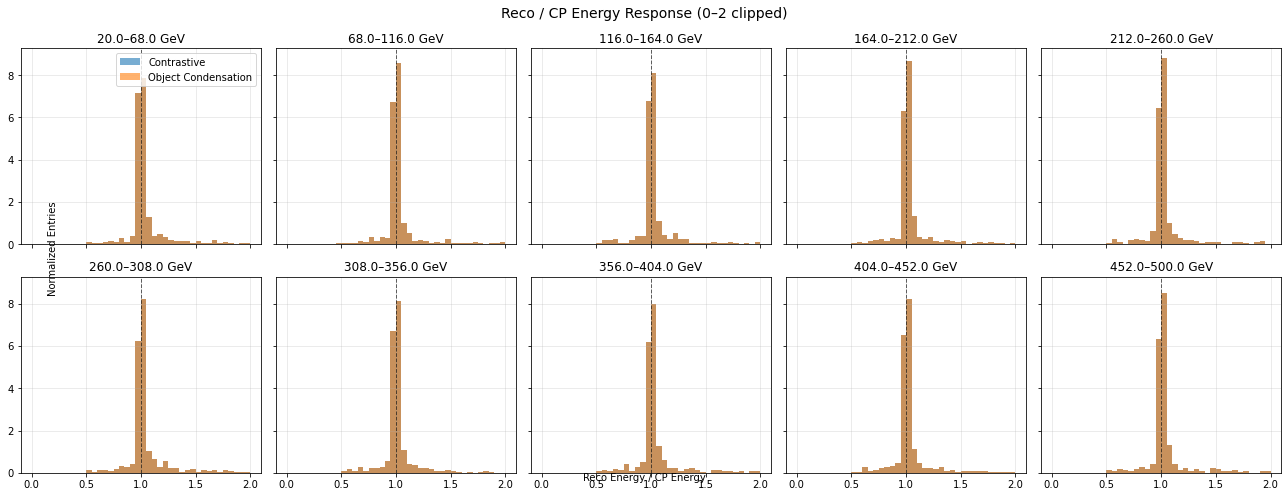

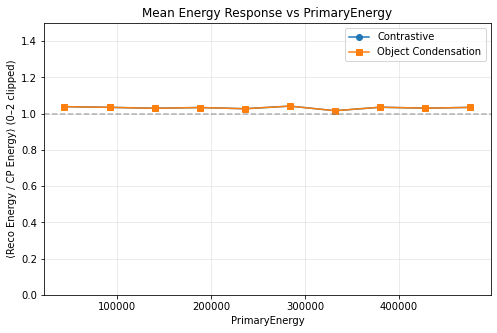

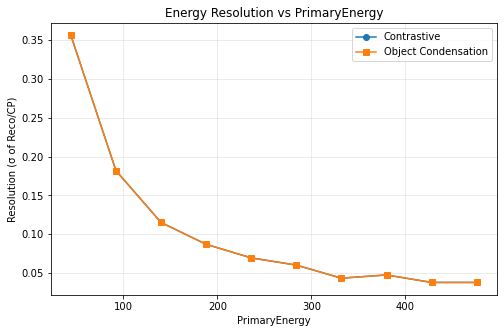

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Energy response vs PrimaryEnergy (Contrastive vs OC)
# Best-matched reco per CP (min RtS), clipped to [0, 2]
# Also computes RESOLUTION = width (std dev) per energy bin

# 1) Define PrimaryEnergy bins

n_bins = 10

all_cp_energy = np.concatenate([
    df_contrastive["PrimaryEnergy"].values,
    df_oc["PrimaryEnergy"].values,
])

energy_bins = np.linspace(all_cp_energy.min(), all_cp_energy.max(), n_bins + 1)
energy_bin_centers = 0.5 * (energy_bins[:-1] + energy_bins[1:])

# 2) Helper: compute response + mean + resolution

def response_by_energy_bin(
    df,
    energy_bins,
    rts_col="shared_energy",
    max_events=300,          # <-- NEW
    random_state=42
):
    response_bins = []
    mean_response = []
    resolution = []

    for i in range(len(energy_bins) - 1):
        low, high = energy_bins[i], energy_bins[i + 1]

        df_bin = df[
            (df["PrimaryEnergy"] >= low) &
            (df["PrimaryEnergy"] < high)
        ]

        responses = []

        # ---- group events ----
        event_groups = list(df_bin.groupby("event_id"))

        # ---- limit events if requested ----
        if max_events is not None and len(event_groups) > max_events:
            rng = np.random.default_rng(random_state)
            event_groups = rng.choice(
                event_groups, size=max_events, replace=False
            )

        # ---- loop over events ----
        for _, df_evt in event_groups:
            for _, df_cp in df_evt.groupby("cp_id"):
                best = df_cp.loc[df_cp[rts_col].idxmax()]

                cp_E   = best["cp_energy"]
                reco_E = best["reco_energy"]

                if cp_E > 0:
                    ratio = reco_E / cp_E
                    if 0.0 <= ratio <= 2.0:
                        responses.append(ratio)

        responses = np.asarray(responses)
        response_bins.append(responses)

        if len(responses):
            mean_response.append(np.mean(responses))
            resolution.append(np.std(responses))
        else:
            mean_response.append(np.nan)
            resolution.append(np.nan)

    return response_bins, np.array(mean_response), np.array(resolution)


# 3) Compute for both models

resp_c, mean_c, res_c = response_by_energy_bin(df_contrastive, energy_bins)
resp_oc, mean_oc, res_oc = response_by_energy_bin(df_oc, energy_bins)

# 4) Overlayed histograms 

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.hist(
        resp_c[i],
        bins=40,
        range=(0, 2),
        density=True,
        alpha=0.6,
        label="Contrastive"
    )
    ax.hist(
        resp_oc[i],
        bins=40,
        range=(0, 2),
        density=True,
        alpha=0.6,
        label="Object Condensation"
    )

    ax.axvline(1.0, linestyle="--", linewidth=1, color="black", alpha=0.6)
    ax.set_title(f"{energy_bins[i]/1e3:.1f}–{energy_bins[i+1]/1e3:.1f} GeV")
    ax.grid(alpha=0.3)

axes[0].legend()
fig.suptitle("Reco / CP Energy Response (0–2 clipped)", fontsize=14)
fig.text(0.5, 0.04, "Reco Energy / CP Energy", ha="center")
fig.text(0.04, 0.5, "Normalized Entries", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

# 5) Mean response vs PrimaryEnergy

plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers, mean_c, "o-", label="Contrastive")
plt.plot(energy_bin_centers, mean_oc, "s-", label="Object Condensation")
plt.axhline(1.0, linestyle="--", color="gray", alpha=0.6)
plt.xlabel("PrimaryEnergy")
plt.ylabel("⟨Reco Energy / CP Energy⟩ (0–2 clipped)")
plt.title("Mean Energy Response vs PrimaryEnergy")
plt.ylim(0,1.5)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 6) Resolution (width) vs PrimaryEnergy

plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers/1000, (res_c*1000*100)/energy_bin_centers, "o-", label="Contrastive")
plt.plot(energy_bin_centers/1000, (res_oc*1000*100)/energy_bin_centers, "s-", label="Object Condensation")
plt.xlabel("PrimaryEnergy")
plt.ylabel("Resolution (σ of Reco/CP)")
plt.title("Energy Resolution vs PrimaryEnergy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
